# 2 · Forecasting and Backtesting

**Sensor Intelligence Platform** — analytical walkthrough (2 / 3)

A forecast is only useful with **honest uncertainty** and an **honest benchmark**. This notebook builds transparent baselines, trains the gradient-boosted tabular model, and compares them with a rolling-origin backtest — scoring both point accuracy and prediction-interval calibration.

1. Construct a forecasting window from one sensor.
2. Baselines: seasonal-naive and rolling-mean.
3. The `TabularForecaster` with recursive multi-step forecasts and intervals.
4. Rolling-origin backtest: MAE / RMSE / MAPE and interval coverage.
5. How forecast error grows with the horizon.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.size": 11,
})

NAVY, ORANGE, TEAL, RED, GREY = "#1f3a5f", "#e8893b", "#2a9d8f", "#c0392b", "#9aa0ad"


## 2.1 Build a clean forecasting window

We simulate a single, fault-free temperature sensor (forecasting accuracy should be measured on representative data, not on injected anomalies) and wrap it in a validated `TimeSeriesWindow`.

In [2]:
from sensor_intelligence.simulation import SensorSimulator, SensorSpec, SimulationConfig
from sensor_intelligence.domain import TimeSeriesWindow

PERIOD = 96
cfg = SimulationConfig(
    sensors=[SensorSpec('temperature', baseline=60.0, daily_amplitude=8.0,
                        trend_per_day=0.15, noise_std=0.6, noise_ar=0.4, unit='C')],
    n_steps=PERIOD * 10, step_seconds=900, seed=21,
)
frame = SensorSimulator(cfg).run()
window = TimeSeriesWindow(
    sensor_id='temperature',
    timestamps=list(frame.timestamp),
    values=[float(v) for v in frame.value],
)
print(f'{len(window)} samples over {len(window) / PERIOD:.0f} days')

960 samples over 10 days


## 2.2 Baselines and the ML model

We forecast the next full day (96 steps). `SeasonalNaiveForecaster` repeats the previous day; `RollingMeanForecaster` projects a flat trailing mean; `TabularForecaster` regresses on lag + calendar features and forecasts recursively. All three return prediction intervals.

In [3]:
from sensor_intelligence.models import (
    SeasonalNaiveForecaster, RollingMeanForecaster, TabularForecaster,
)

H = PERIOD
train = TimeSeriesWindow(sensor_id='temperature',
                         timestamps=window.timestamps[:-H],
                         values=window.values[:-H])
actual = window.values[-H:]
future_t = window.timestamps[-H:]

forecasts = {
    'seasonal_naive': SeasonalNaiveForecaster(period=PERIOD).forecast(train, H),
    'rolling_mean': RollingMeanForecaster(window_size=PERIOD).forecast(train, H),
    'tabular_ml': TabularForecaster(n_lags=2 * PERIOD).fit(train).forecast(H),
}
print('forecasts:', list(forecasts))

forecasts: ['seasonal_naive', 'rolling_mean', 'tabular_ml']


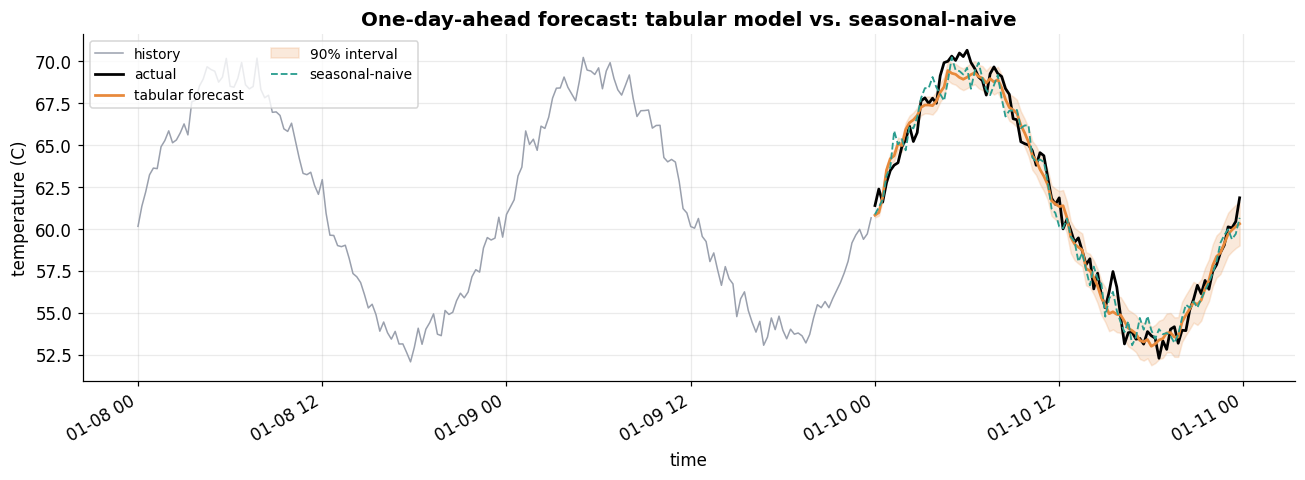

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
hist_t = window.timestamps[-3 * H:-H]
hist_v = window.values[-3 * H:-H]
ax.plot(hist_t, hist_v, color=GREY, lw=1, label='history')
ax.plot(future_t, actual, color='black', lw=1.8, label='actual')
fc = forecasts['tabular_ml']
ax.plot(future_t, fc.mean, color=ORANGE, lw=1.8, label='tabular forecast')
ax.fill_between(future_t, fc.lower, fc.upper, color=ORANGE, alpha=0.18,
                label=f'{fc.interval_level:.0%} interval')
ax.plot(future_t, forecasts['seasonal_naive'].mean, color=TEAL, lw=1.2,
        ls='--', label='seasonal-naive')
ax.set(title='One-day-ahead forecast: tabular model vs. seasonal-naive',
       xlabel='time', ylabel='temperature (C)')
ax.legend(loc='upper left', ncol=2, fontsize=9)
fig.autofmt_xdate()
fig.tight_layout()

## 2.3 Scoring the forecasts

`forecast_metrics` reports point accuracy (MAE / RMSE / MAPE) and, when intervals are present, **empirical coverage** (what fraction of actuals fell inside the nominal interval) and mean width. Coverage close to the nominal 90% means the uncertainty is well calibrated.

In [5]:
from sensor_intelligence.tracking import forecast_metrics

rows = []
for name, fc in forecasts.items():
    m = forecast_metrics(actual, fc.mean, fc.lower, fc.upper)
    rows.append({'model': name, **{k: round(v, 3) for k, v in m.items()}})
scores = pd.DataFrame(rows).set_index('model')
scores

,mae,rmse,mape,interval_coverage,interval_width
model,,,,,
seasonal_naive,0.717,0.876,1.165,0.927,3.097
rolling_mean,5.108,5.781,8.389,1.000,18.522
tabular_ml,0.594,0.756,0.963,0.698,1.740


## 2.4 Rolling-origin backtest

A single split is noisy. A **rolling-origin** backtest re-fits and re-scores at several cut points and averages, giving a far more reliable comparison. The platform's `backtest` helper holds out the tail of any window and scores any forecaster through a uniform signature.

In [6]:
from sensor_intelligence.tracking import backtest

def make_fns():
    return {
        'seasonal_naive': lambda w, h: SeasonalNaiveForecaster(period=PERIOD).forecast(w, h),
        'rolling_mean': lambda w, h: RollingMeanForecaster(window_size=PERIOD).forecast(w, h),
        'tabular_ml': lambda w, h: TabularForecaster(n_lags=2 * PERIOD).fit(w).forecast(h),
    }

origins = [PERIOD * k for k in (4, 5, 6, 7)]   # hold out the last day at 4 cut points
records = []
for cut in origins:
    sub = TimeSeriesWindow(sensor_id='temperature',
                           timestamps=window.timestamps[:cut + PERIOD],
                           values=window.values[:cut + PERIOD])
    for name, fn in make_fns().items():
        _, m = backtest(fn, sub, horizon=PERIOD)
        records.append({'model': name, 'origin': cut, **m})

bt = pd.DataFrame(records)
agg = bt.groupby('model')[['mae', 'rmse', 'mape', 'interval_coverage']].mean().round(3)
agg.sort_values('mae')

,mae,rmse,mape,interval_coverage
model,,,,
tabular_ml,0.702,0.874,1.147,0.734
seasonal_naive,0.794,0.991,1.303,0.867
rolling_mean,5.101,5.701,8.441,1.000


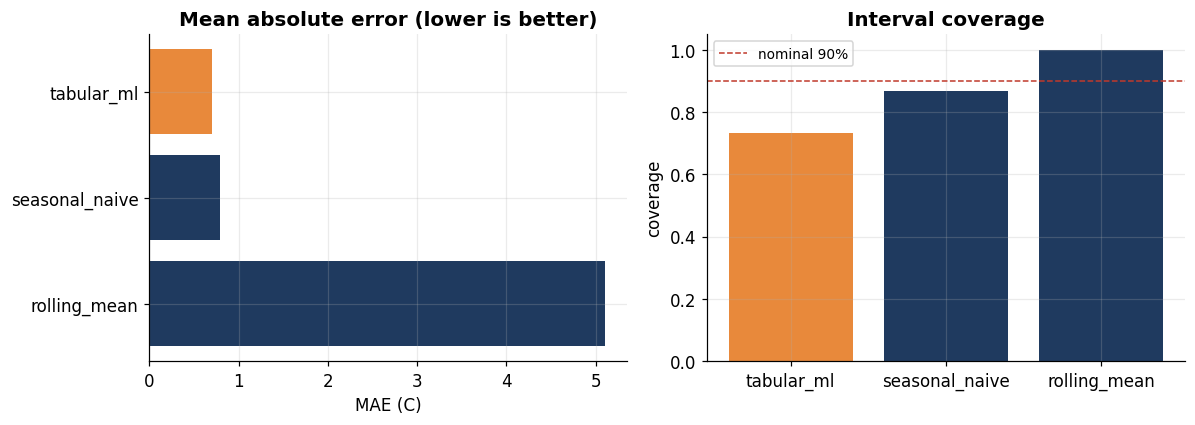

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
order = agg.sort_values('mae').index
colors = [ORANGE if m == 'tabular_ml' else NAVY for m in order]
a1.barh(order, agg.loc[order, 'mae'], color=colors)
a1.set(title='Mean absolute error (lower is better)', xlabel='MAE (C)')
a1.invert_yaxis()
a2.bar(order, agg.loc[order, 'interval_coverage'], color=colors)
a2.axhline(0.9, color=RED, ls='--', lw=1, label='nominal 90%')
a2.set(title='Interval coverage', ylabel='coverage', ylim=(0, 1.05))
a2.legend(fontsize=9)
fig.tight_layout()

## 2.5 How error grows with the horizon

Recursive multi-step forecasting compounds error as it projects further out. The platform reflects this by widening prediction intervals with √horizon; here we confirm the realised error grows similarly.

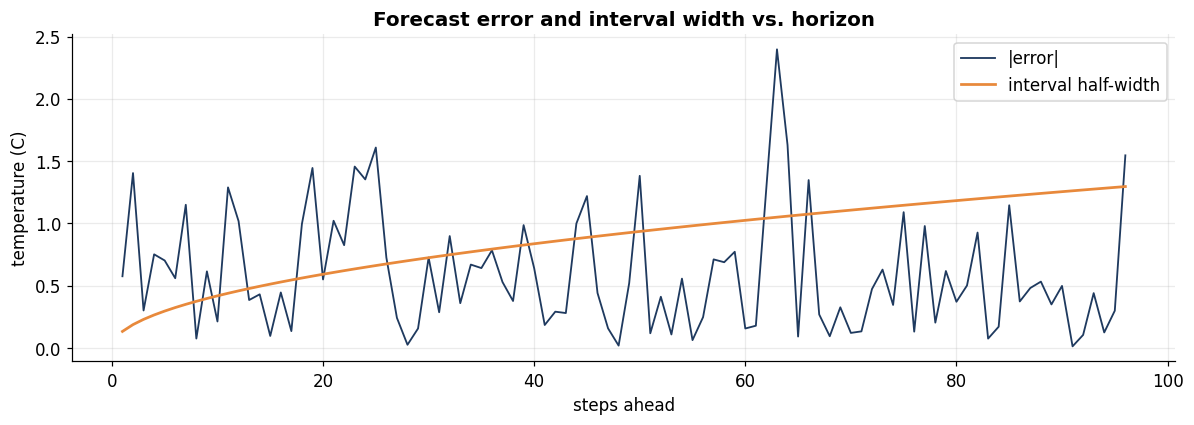

In [8]:
fc = TabularForecaster(n_lags=2 * PERIOD).fit(train).forecast(H)
step_err = np.abs(np.array(fc.mean) - np.array(actual))
interval_half = (np.array(fc.upper) - np.array(fc.lower)) / 2
steps = np.arange(1, H + 1)
fig, ax = plt.subplots()
ax.plot(steps, step_err, color=NAVY, lw=1.2, label='|error|')
ax.plot(steps, interval_half, color=ORANGE, lw=1.8, label='interval half-width')
ax.set(title='Forecast error and interval width vs. horizon',
       xlabel='steps ahead', ylabel='temperature (C)')
ax.legend()
fig.tight_layout()

## Takeaways

- The **tabular model** improves on the baselines on MAE/RMSE while keeping interval coverage near the nominal level — uncertainty you can trust.
- A **rolling-origin backtest** is the honest way to compare forecasters; a single split can mislead.
- Error and interval width both **grow with the horizon**, as expected from recursive forecasting.

**Next:** [3 · Anomaly, Drift and Alerting](03_anomaly_drift_and_alerting.ipynb).